Subjects being used:
['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010', 'S011', 'S012', 'S013', 'S014', 'S015', 'S016', 'S017', 'S018', 'S019', 'S020']
Loading: eegmmidb\S001\S001R04.edf
Using reference sampling frequency: 160.0 Hz
Loading: eegmmidb\S001\S001R08.edf
Loading: eegmmidb\S001\S001R12.edf
Loading: eegmmidb\S002\S002R04.edf
Loading: eegmmidb\S002\S002R08.edf
Loading: eegmmidb\S002\S002R12.edf
Loading: eegmmidb\S003\S003R04.edf
Loading: eegmmidb\S003\S003R08.edf
Loading: eegmmidb\S003\S003R12.edf
Loading: eegmmidb\S004\S004R04.edf
Loading: eegmmidb\S004\S004R08.edf
Loading: eegmmidb\S004\S004R12.edf
Loading: eegmmidb\S005\S005R04.edf
Loading: eegmmidb\S005\S005R08.edf
Loading: eegmmidb\S005\S005R12.edf
Loading: eegmmidb\S006\S006R04.edf
Loading: eegmmidb\S006\S006R08.edf
Loading: eegmmidb\S006\S006R12.edf
Loading: eegmmidb\S007\S007R04.edf
Loading: eegmmidb\S007\S007R08.edf
Loading: eegmmidb\S007\S007R12.edf
Loading: eegmmidb\S008\S008R04.edf
Loa

ipykernel_10360\4291755072.py:122: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = raw.compute_psd().plot(show=False)


Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]

Annotation Mapping:
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

Using event mapping:
{'left': 2, 'right': 3}

Creating epochs...
X shape: (900, 64, 481)
y shape: (900,)

Generating left vs right average plot...
combining channels using "mean"
combining channels using "mean"

Train shape: (720, 64, 481)
Test shape: (180, 64, 481)

Training EEG classifier...
Computing rank from data with rank=None
    Using tolerance 0.00085 (2.2e-16 eps * 64 dim * 6e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.

Accuracy: 0.4666666666666667

Classification Report:
              precision    recall  f1-score   support

        left       0.47      0.49      0.48        91
       right       0.46      0.44  

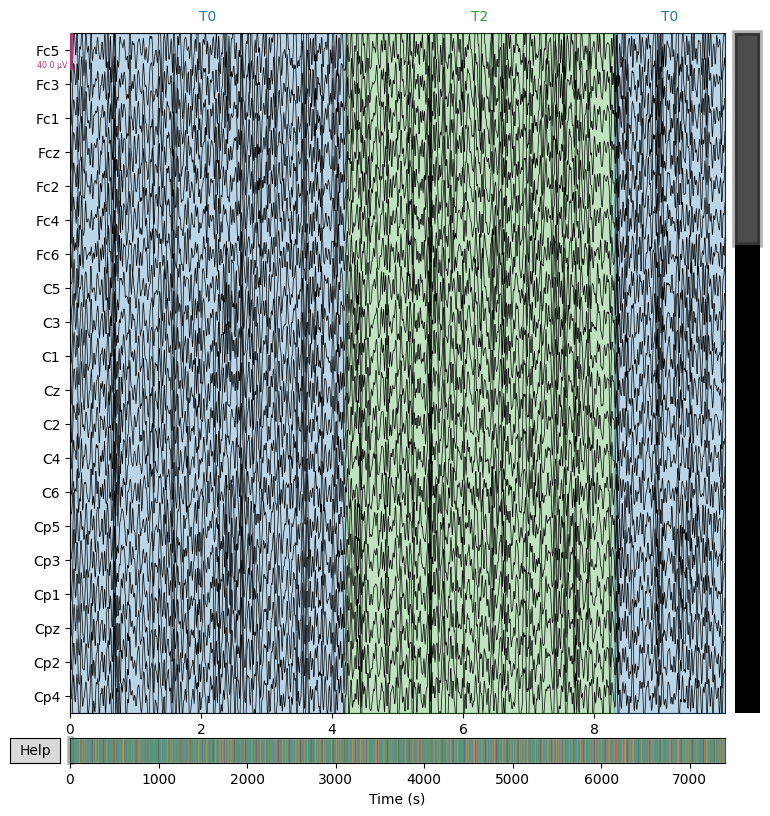

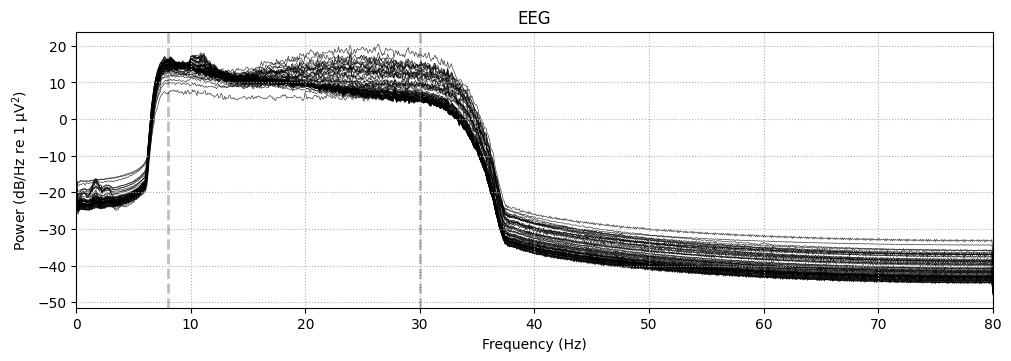

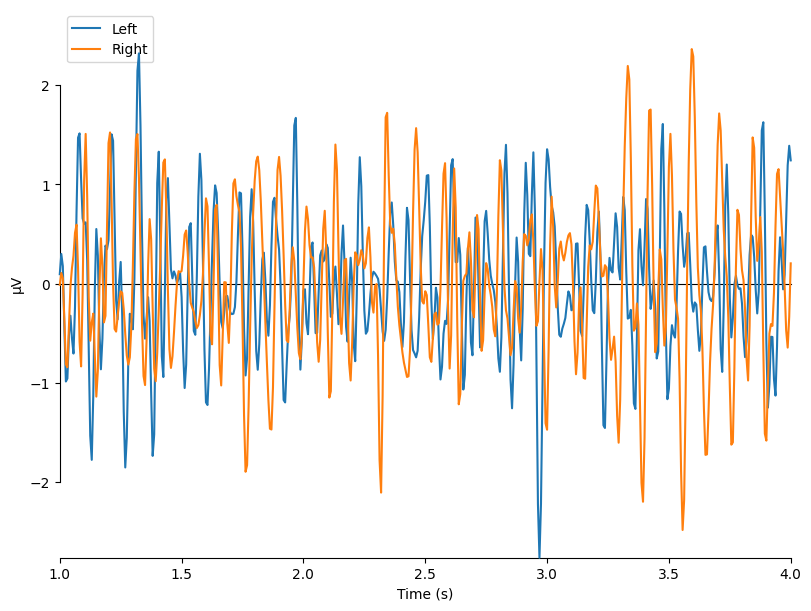

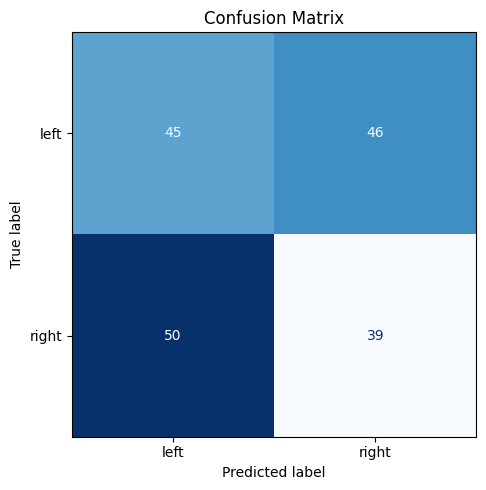


Demo Prediction
Predicted: right
Actual   : left

DONE! Files saved in /results
- raw_waveforms.png
- psd_plot.png
- left_vs_right_evoked.png
- confusion_matrix.png
- model_performance_report.txt
- demo_prediction.txt


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mne

from mne.io import read_raw_edf, concatenate_raws
from mne.decoding import CSP

from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# =========================
# 1. SETTINGS
# =========================
BASE_DIR = "eegmmidb"     # your dataset folder
RUNS = [4, 8, 12]         # left/right motor imagery
RESULTS_DIR = "results"

# Optional: use only first N subjects to keep it lighter
MAX_SUBJECTS = 20   # change to None if you want all subjects

os.makedirs(RESULTS_DIR, exist_ok=True)

# =========================
# 2. FIND SUBJECTS
# =========================
subject_folders = sorted([
    folder for folder in os.listdir(BASE_DIR)
    if folder.startswith("S") and os.path.isdir(os.path.join(BASE_DIR, folder))
])

if MAX_SUBJECTS is not None:
    subject_folders = subject_folders[:MAX_SUBJECTS]

if not subject_folders:
    raise ValueError(f"No subject folders found inside {BASE_DIR}")

print("Subjects being used:")
print(subject_folders)

# =========================
# 3. LOAD EDF FILES SAFELY
# =========================
raws = []
used_files = []
skipped_files = []

expected_sfreq = None

for subject in subject_folders:
    for run in RUNS:
        file_path = os.path.join(BASE_DIR, subject, f"{subject}R{run:02d}.edf")

        if not os.path.exists(file_path):
            skipped_files.append((file_path, "File not found"))
            continue

        try:
            print(f"Loading: {file_path}")
            raw = read_raw_edf(file_path, preload=True, verbose=False)

            sfreq = raw.info["sfreq"]

            if expected_sfreq is None:
                expected_sfreq = sfreq
                print(f"Using reference sampling frequency: {expected_sfreq} Hz")

            if sfreq != expected_sfreq:
                skipped_files.append((file_path, f"Sampling frequency mismatch ({sfreq} != {expected_sfreq})"))
                print(f"Skipping {file_path} بسبب sfreq mismatch")
                continue

            raws.append(raw)
            used_files.append(file_path)

        except Exception as e:
            skipped_files.append((file_path, str(e)))
            print(f"Skipping {file_path} بسبب error: {e}")

if not raws:
    raise ValueError("No valid EDF files loaded.")

print(f"\nTotal valid EDF files loaded: {len(raws)}")
print(f"Total skipped files: {len(skipped_files)}")

# =========================
# 4. CONCATENATE
# =========================
print("\nConcatenating valid EEG recordings...")
raw = concatenate_raws(raws)

# Clean channel names
raw.rename_channels(lambda x: x.strip("."))

# Set montage
try:
    raw.set_montage("standard_1005")
except Exception as e:
    print("Montage warning:", e)

print("\nCombined Raw Info:")
print(raw)

# =========================
# 5. PREPROCESSING
# =========================
print("\nFiltering EEG (8-30 Hz)...")
raw.filter(8., 30., fir_design="firwin", skip_by_annotation="edge", verbose=False)

# =========================
# 6. SIGNAL VISUALIZATION
# =========================
print("\nGenerating signal visualization graphs...")

# Raw waveform
fig = raw.plot(start=0, duration=10, n_channels=20, show=False)
fig.savefig(os.path.join(RESULTS_DIR, "raw_waveforms.png"), dpi=300, bbox_inches="tight")

# PSD
fig = raw.compute_psd().plot(show=False)
fig.savefig(os.path.join(RESULTS_DIR, "psd_plot.png"), dpi=300, bbox_inches="tight")

# =========================
# 7. EXTRACT EVENTS
# =========================
events, event_id = mne.events_from_annotations(raw)

print("\nAnnotation Mapping:")
print(event_id)

wanted = {}
if "T1" in event_id:
    wanted["left"] = event_id["T1"]
if "T2" in event_id:
    wanted["right"] = event_id["T2"]

if len(wanted) != 2:
    raise ValueError(f"Could not find T1/T2 annotations correctly. Found: {event_id}")

print("\nUsing event mapping:")
print(wanted)

# =========================
# 8. CREATE EPOCHS
# =========================
print("\nCreating epochs...")
tmin, tmax = 1.0, 4.0

epochs = mne.Epochs(
    raw,
    events,
    event_id=wanted,
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True,
    verbose=False
)

labels = epochs.events[:, -1]
left_code = wanted["left"]
right_code = wanted["right"]

y = np.where(labels == left_code, 0, 1)
X = epochs.get_data()

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================
# 9. LEFT VS RIGHT VISUALIZATION
# =========================
available_motor = [ch for ch in ["C3", "Cz", "C4"] if ch in epochs.ch_names]

if len(available_motor) >= 1:
    print("\nGenerating left vs right average plot...")
    epochs_motor = epochs.copy().pick(available_motor)
    ev_left = epochs_motor["left"].average()
    ev_right = epochs_motor["right"].average()

    fig = mne.viz.plot_compare_evokeds(
        {"Left": ev_left, "Right": ev_right},
        combine="mean",
        show=False
    )
    fig[0].savefig(
        os.path.join(RESULTS_DIR, "left_vs_right_evoked.png"),
        dpi=300,
        bbox_inches="tight"
    )

# =========================
# 10. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# 11. MODEL: CSP + LDA
# =========================
clf = Pipeline([
    ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
    ("lda", LinearDiscriminantAnalysis())
])

print("\nTraining EEG classifier...")
clf.fit(X_train, y_train)

# =========================
# 12. EVALUATION
# =========================
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["left", "right"])

print("\nAccuracy:", accuracy)
print("\nClassification Report:")
print(report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["left", "right"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=300)
plt.show()

# =========================
# 13. SAVE REPORT
# =========================
report_lines = [
    "EEG Signal Analysis - Left/Right Motor Imagery",
    "==============================================",
    f"Subjects used: {len(subject_folders)}",
    f"Runs used: {RUNS}",
    f"Reference sampling frequency: {expected_sfreq} Hz",
    f"Total valid EDF files loaded: {len(used_files)}",
    f"Total skipped files: {len(skipped_files)}",
    f"Epoch window: {tmin} to {tmax} sec",
    f"Accuracy: {accuracy:.4f}",
    "",
    "Classification Report:",
    report,
    "",
    "USED FILES:"
]

report_lines.extend(used_files)

report_lines.append("\nSKIPPED FILES:")
for f, reason in skipped_files:
    report_lines.append(f"{f} --> {reason}")

with open(os.path.join(RESULTS_DIR, "model_performance_report.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

# =========================
# 14. DEMO PREDICTION
# =========================
sample_idx = 0
pred = clf.predict(X_test[sample_idx:sample_idx+1])[0]
actual = y_test[sample_idx]

label_map = {0: "left", 1: "right"}

print("\nDemo Prediction")
print("Predicted:", label_map[pred])
print("Actual   :", label_map[actual])

with open(os.path.join(RESULTS_DIR, "demo_prediction.txt"), "w", encoding="utf-8") as f:
    f.write("Demo Prediction\n")
    f.write(f"Predicted: {label_map[pred]}\n")
    f.write(f"Actual: {label_map[actual]}\n")

print("\n==============================")
print("DONE! Files saved in /results")
print("==============================")
print("- raw_waveforms.png")
print("- psd_plot.png")
print("- left_vs_right_evoked.png")
print("- confusion_matrix.png")
print("- model_performance_report.txt")
print("- demo_prediction.txt")